# FOMC Event Driven Returns

In [81]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [10]:
path       = r"A:\GitHub\FOMCDrift\data\Guides\FedMeetings.xlsx"
df_meeting = (pd
    .read_excel(io = path)
    .assign(date = lambda x: pd.to_datetime(x.date).dt.date)
    .reset_index()
    .rename(columns = {"index": "meeting_id"})
    .assign(meeting_id = lambda x: x.meeting_id + 1))

In [58]:
path     = r"A:\GitHub\FOMCDrift\data\FirstRateData"
files    = os.listdir(path)
df_lists = [] 

for file in files: 

    tmp_path = os.path.join(path, file)
    df_add   = (pd
        .read_parquet(path = tmp_path)
        .rename(columns = {"date": "datetime"})
        .loc[lambda x: x.variable == "close"]
        .assign(date = lambda x: pd.to_datetime(x.datetime).dt.date)
        .merge(right = df_meeting, how = "inner", on = ["date"])
        .assign(time = lambda x: x.prep_date.dt.time))
    
    df_lists.append(df_add)

In [59]:
df_fut = pd.concat(df_lists)

<Axes: xlabel='time'>

<Axes: xlabel='time'>

<Axes: xlabel='time'>

<Axes: xlabel='time'>

<Axes: xlabel='time'>

<Axes: xlabel='time'>

<Axes: xlabel='time'>

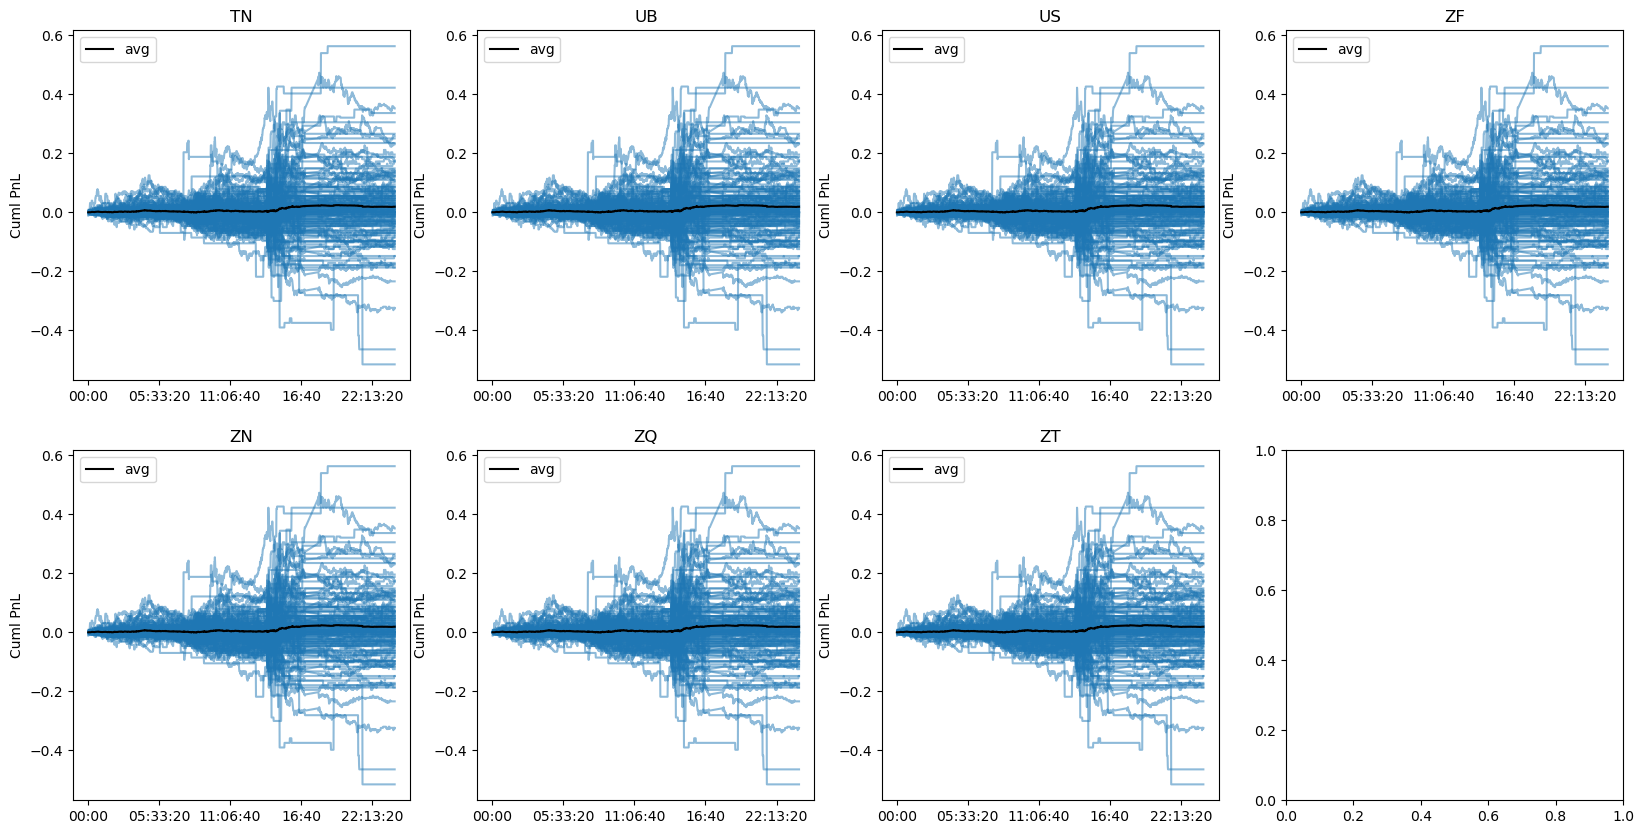

In [63]:
tickers   = df_fut.ticker.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize=(20, 10))

for ticker, ax in zip(tickers, axes.flatten()):

    df_wider = (df_add
        .pivot(index="time", columns="meeting_id", values="value")
        .ffill()
        .diff())
    
    (df_wider
        .cumsum()
        .plot(
            legend = False, 
            ax     = ax,
            alpha  = 0.5,
            color  = "tab:blue"))
    
    (df_wider
        .mean(axis = 1)
        .to_frame(name = "avg")
        .cumsum()
        .plot(ax = ax, color = "black"))

    ax.set_title(ticker)
    ax.set_xlabel("")
    ax.set_ylabel("Cuml PnL")

In [75]:
df_avg = (df_fut
    [["value", "ticker", "meeting_id", "time"]]
    .set_index("time")
    .groupby(["ticker", "meeting_id"])
    .apply(lambda x: x.sort_index().value.diff())
    .reset_index()
    .drop(columns = ["meeting_id"])
    .groupby(["time", "ticker"])
    .agg("mean")
    .reset_index())

$\downarrow$ need to lag bar for close

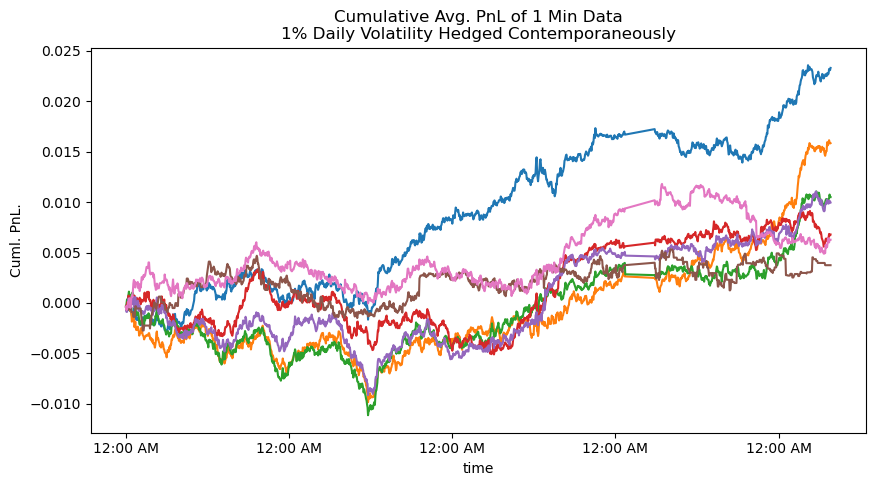

In [103]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 5))

(
    df_avg
    .rename(columns={"ticker": ""})
    .pivot(index="time", columns="", values="value")
    .fillna(0)
    .apply(
        lambda x: x * (
            0.01 /
            (x.ewm(span=100, adjust=False).std() * np.sqrt(1440))
        )
    )
    .cumsum()
    .plot(
        ylabel="Cuml. PnL.",
        legend=False,
        title="Cumulative Avg. PnL of 1 Min Data\n"
              "1% Daily Volatility Hedged Contemporaneously",
        ax=ax
    )
)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%I:%M %p"))

plt.show()